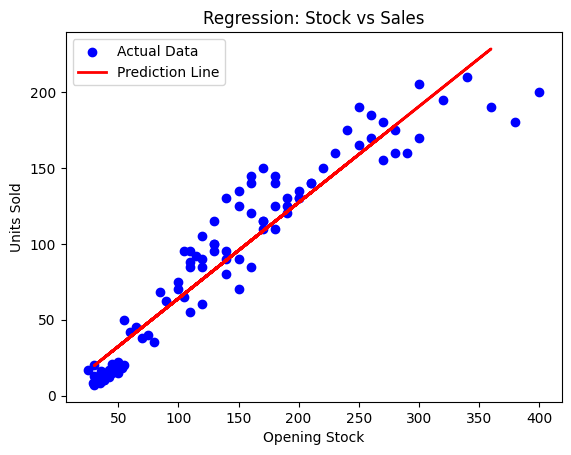

Predicted Sales for 200 Stock: 127.22


c:\Users\Toshit Dwivedi\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

data = pd.read_csv("C:\\Users\\Toshit Dwivedi\\Desktop\\Smart_Stock_Inventory_Optimization_For_Retail_Stores-main\\dataset\\updated_dataset.csv")

x = data[["Opening_Stock"]]
y = data[["Units_Sold"]]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


model = LinearRegression()
model.fit(x_train, y_train)


pred = model.predict(x_test)

plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x_test, pred, color='red', linewidth=2, label='Prediction Line')
plt.xlabel("Opening Stock")
plt.ylabel("Units Sold")
plt.title("Regression: Stock vs Sales")
plt.legend()
plt.show()

new_stock = [[200]]
predicted_sales = model.predict(new_stock)
print(f"Predicted Sales for 200 Stock: {predicted_sales[0][0]:.2f}")

In [2]:
df = pd.read_csv(r"C:\Users\Toshit Dwivedi\Desktop\Smart_Stock_Inventory_Optimization_For_Retail_Stores-main\dataset\updated_dataset.csv")
df = df.dropna(subset=['Opening_Stock', 'Remaining_Stock', 'Units_Sold'])
df = df[(df['Opening_Stock'] >= 0) & (df['Remaining_Stock'] >= 0)]
df.head()

,Product_ID,Product_Name,Month,Month_Num,Units_Sold,Price,Opening_Stock,Total_Sales_Value,Revenue_Per_Unit,Remaining_Stock,Stock_Turnover_Rate
0,P001,Rice,Jan,1,130,60,200,7800,60.0,70,65.00
1,P001,Rice,Feb,2,125,60,190,7500,60.0,65,65.79
2,P001,Rice,Mar,3,140,60,180,8400,60.0,40,77.78
3,P001,Rice,Apr,4,110,60,170,6600,60.0,60,64.71
4,P001,Rice,May,5,145,60,160,8700,60.0,15,90.62


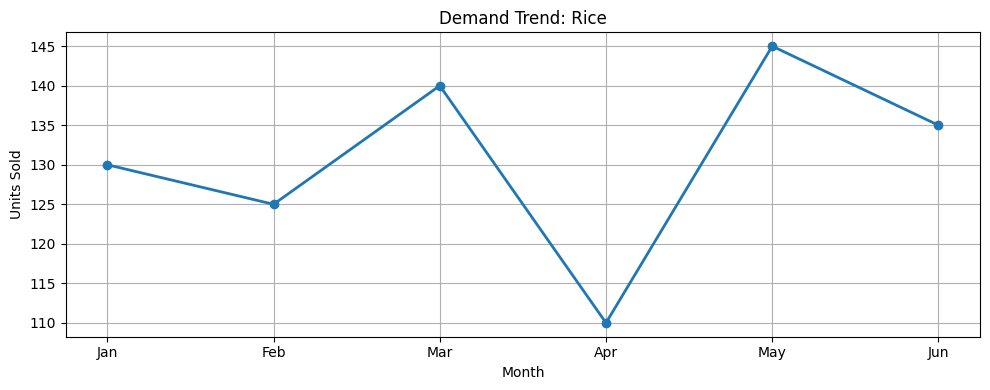

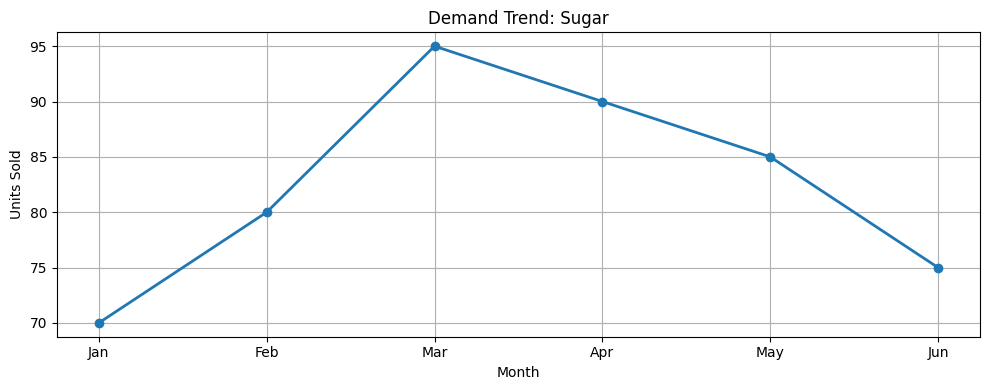

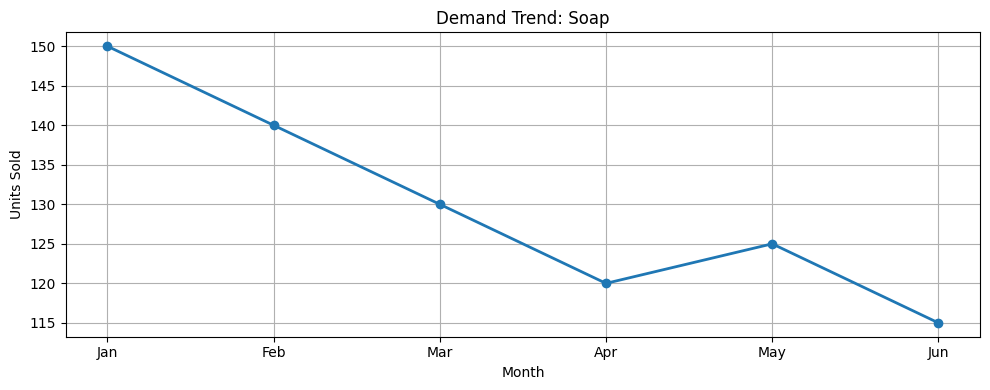

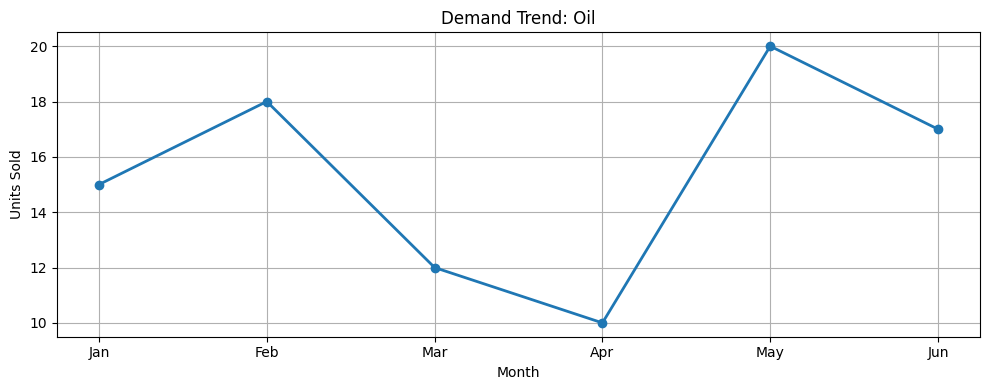

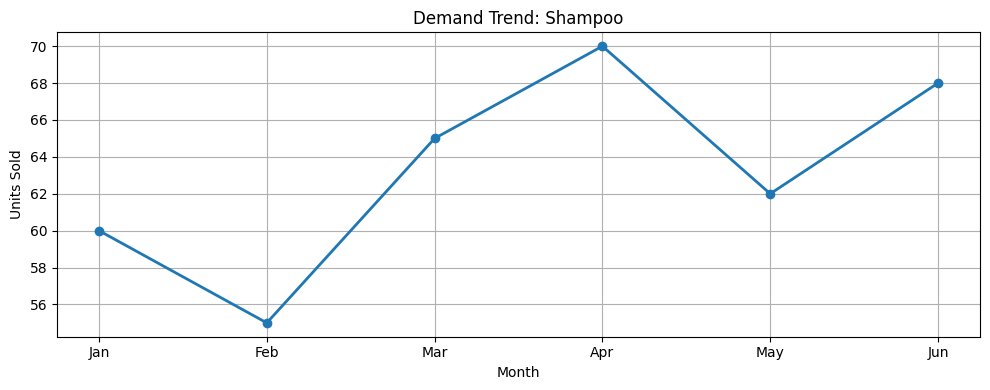

In [ ]:
products = df['Product_Name'].unique()

for product in products:
    product_data = df[df['Product_Name'] == product].sort_values('Month_Num')
    plt.figure(figsize=(10, 4))
    plt.plot(product_data['Month'], product_data['Units_Sold'], marker='o', linewidth=2)
    plt.title(f'Demand Trend: {product}')
    plt.xlabel('Month')
    plt.ylabel('Units Sold')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
stock_comparison = pd.DataFrame([{
    'Product': product,
    'Current_Stock': df[df['Product_Name'] == product]['Remaining_Stock'].iloc[-1],
    'Optimal_Stock': round(df[df['Product_Name'] == product]['Units_Sold'].mean() * 1.2)
} for product in products])

x = range(len(stock_comparison))
plt.figure(figsize=(10, 6))
plt.bar([i - 0.2 for i in x], stock_comparison['Current_Stock'], 0.4, label='Current', color='red')
plt.bar([i + 0.2 for i in x], stock_comparison['Optimal_Stock'], 0.4, label='Optimal', color='green')
plt.xlabel('Product')
plt.ylabel('Stock Level')
plt.title('Current vs Optimal Stock')
plt.xticks(x, stock_comparison['Product'])
plt.legend()
plt.tight_layout()
plt.show()
print(stock_comparison)

NameError: name 'stock_comparison' is not defined

<Figure size 1000x600 with 0 Axes>

In [ ]:
low_stock = stock_comparison[stock_comparison['Current_Stock'] < 50]['Product'].tolist()
overstock = stock_comparison[stock_comparison['Current_Stock'] > 200]['Product'].tolist()

print("Low-Stock Items:", low_stock if low_stock else "None")
print("Overstock Items:", overstock if overstock else "None")

NameError: name 'stock_comparison' is not defined

In [ ]:
stock_comparison['Difference'] = stock_comparison['Optimal_Stock'] - stock_comparison['Current_Stock']
stock_comparison['Action'] = stock_comparison['Difference'].apply(lambda x: 'REORDER' if x > 0 else ('REDUCE' if x < -50 else 'MAINTAIN'))
stock_comparison['Quantity'] = stock_comparison['Difference'].abs().round().astype(int)

reorder_table = stock_comparison[['Product', 'Current_Stock', 'Optimal_Stock', 'Action', 'Quantity']]
reorder_table.to_csv(r"C:\Users\Toshit Dwivedi\Desktop\Smart_Stock_Inventory_Optimization_For_Retail_Stores-main\output\reorder_recommendations.csv", index=False)
print("Reorder Recommendations:")
reorder_table

NameError: name 'stock_comparison' is not defined